In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ps2mult1.csv

In [3]:
df1 = pd.read_csv('ps2mult1.csv', header = None)

In [4]:
Y1 = np.array(df1.iloc[:, 2])
X1 = np.c_[np.ones(len(Y1)), np.array(df1.iloc[:, 0:2])]

## Beta

In [5]:
B_hat_1 = np.linalg.inv(X1.T @ X1) @ (X1.T @ Y1)
print(f'b_0: {B_hat_1[0]}, b_1: {B_hat_1[1]}, b_2: {B_hat_1[2]}')

b_0: 0.987680803133528, b_1: 2.0775010150046374, b_2: 3.0161893641291138


## Fitting

In [6]:
Y_fit_1 = X1 @ B_hat_1

## Residuals

In [7]:
e1 = Y1 - Y_fit_1
print(f'Min: {min(e1)}')
print(f'Max: {max(e1)}')

Min: -0.9288486791979178
Max: 1.2558664704664821


## Histogram

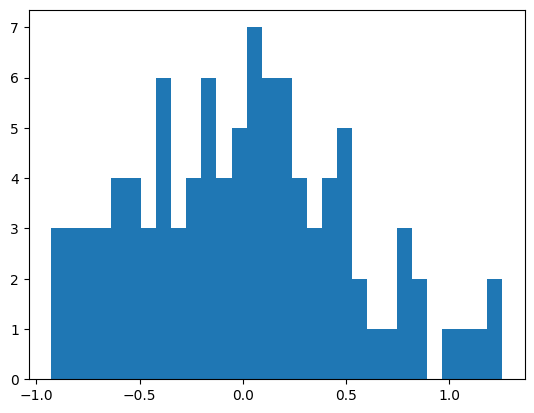

In [8]:
plt.hist(e1, bins = 30);

# ps2mult2.csv

In [9]:
df2 = pd.read_csv('ps2mult2.csv', header = None)

In [10]:
Y2 = np.array(df2[1])
X2_normal = np.array(df2[0])
X2_inverse = 1 / X2_normal
X2 = np.c_[np.ones(len(Y2)), np.c_[X2_normal, X2_inverse]]

## Beta

In [11]:
B_hat_2 = np.linalg.inv(X2.T @ X2) @ (X2.T @ Y2)
print(f'b_0: {B_hat_2[0]}, b_1: {B_hat_2[1]}, b_2: {B_hat_2[2]}')

b_0: 3.442541830938289, b_1: 1.0024625080898737, b_2: 4.045378830871094


## Fitting

In [12]:
Y_fit_2 = X2 @ B_hat_2
xs = np.linspace(0.1, 8, 500)
Y_plot = [B_hat_2[0] + B_hat_2[1] * x + B_hat_2[2] * (1 / x) for x in xs]

## Plotting

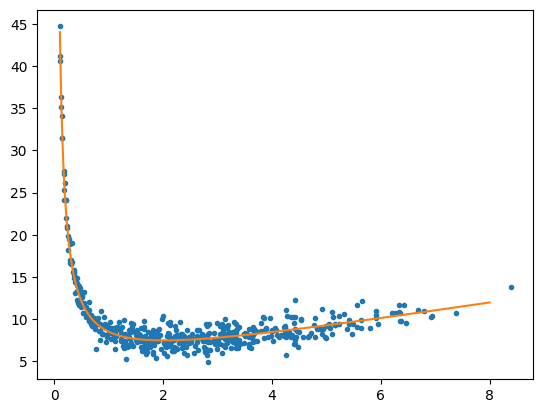

In [13]:
plt.plot(X2_normal, Y2, '.')
plt.plot(xs, Y_plot);

## Residuals

In [14]:
e2 = Y2 - Y_fit_2
print(f'Min: {min(e2)}')
print(f'Max: {max(e2)}')

Min: -3.0523854235037042
Max: 3.4527874227259794


## Histogram

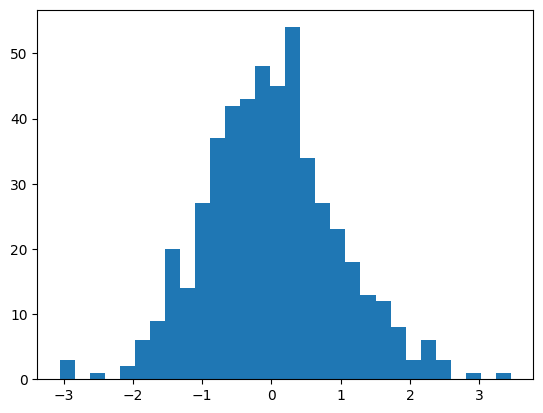

In [15]:
plt.hist(e2, bins = 30);

# ps2mult3.csv

In [16]:
df3 = pd.read_csv('ps2mult3.csv', header = None)

In [17]:
Z3 = df3[2]
XY3 = np.c_[np.ones(len(Z3)), np.array(df3.iloc[:, 0:2])]

## Beta

In [18]:
B_hat_3 = np.linalg.inv(XY3.T @ XY3) @ (XY3.T @ Z3)
print(f'b_0: {B_hat_3[0]}, b_1: {B_hat_3[1]}, b_2: {B_hat_3[2]}')

b_0: 17.89056972460882, b_1: 0.3842373572775549, b_2: 0.8185666457180585


## Computing Z_hat

In [19]:
Z_hat = [B_hat_3[0] + B_hat_3[1] * XY3[i][1] + B_hat_3[2] * XY3[i][2] for i in range(len(Z3))]

## Compare to Z

In [20]:
e3 = Z3 - Z_hat

## Residuals

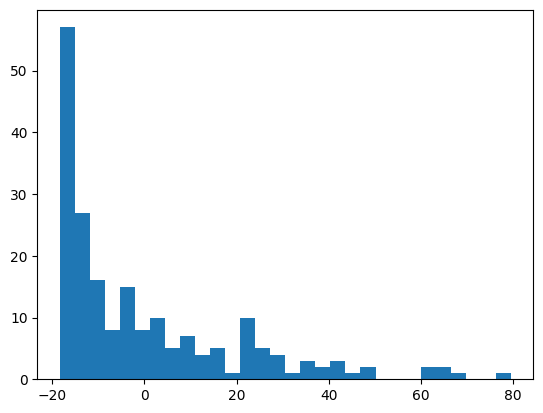

In [21]:
plt.hist(e3, bins = 30);

### Bad model, try quadratic in X and Y + NOISE

In [22]:
X_squared = df3[0] * df3[0]
X_Y = df3[0] * df3[1]
Y_squared = df3[1] * df3[1]

input_quad = np.c_[np.ones(len(Z3)), np.c_[X_squared, np.c_[X_Y, np.c_[Y_squared, np.c_[df3[0], df3[1]]]]]]
output_quad = Z3

## Beta

In [23]:
quad_b_hat = np.linalg.inv(input_quad.T @ input_quad) @ (input_quad.T @ output_quad)
print(f'b_0: {quad_b_hat[0]}, \nb_1: {quad_b_hat[1]}, \nb_2: {quad_b_hat[2]}, \nb_3: {quad_b_hat[3]}, \nb_4: {quad_b_hat[4]}, \nb_5: {quad_b_hat[5]}')

b_0: -0.003005831051950736, 
b_1: 1.0006612696839463, 
b_2: -1.9997958585570133, 
b_3: 0.9996878627804846, 
b_4: 1.0030742622647026, 
b_5: 0.00043674949473837543


## Fitting

In [24]:
def xq(i): return XY3[i][1]
def yq(i): return XY3[i][2]

Z_quad = [(quad_b_hat[0] + 
          quad_b_hat[1] * xq(i) * xq(i) + 
          quad_b_hat[2] * xq(i) * yq(i) + 
          quad_b_hat[3] * yq(i) * yq(i) +
          quad_b_hat[4] * xq(i) + 
          quad_b_hat[5] * yq(i)) for i in range(len(output_quad))]

## Residuals

In [25]:
quad_e = Z_quad - output_quad
print(f'Min: {min(quad_e)}')
print(f'Max: {max(quad_e)}')

Min: -0.1042600184332354
Max: 0.09903574044012942


## Histogram

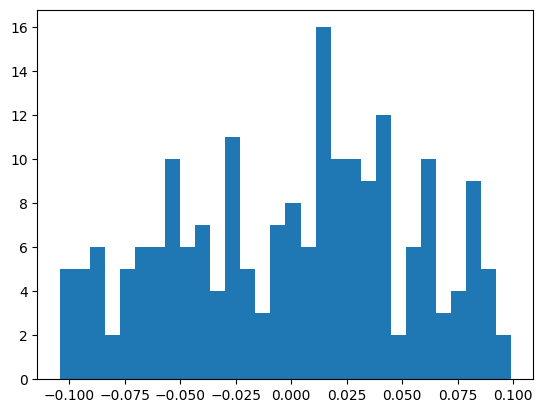

In [26]:
plt.hist(quad_e, bins = 30);

# ps2norm1.csv

In [29]:
norm1 = pd.read_csv('ps2norm1.csv', header = None)
norm1.head()

,0,1,2,3
0,0.698673,0.971810,0.121021,0.766471
1,0.556531,0.632512,0.830847,9.919968
2,0.140140,0.958269,0.418317,5.573671
3,0.285723,0.886354,0.082031,2.500926
4,0.555369,0.523184,0.176028,5.496685


In [38]:
y_norm1 = np.array(norm1.iloc[:, 3])
x_norm1 = np.c_[np.ones(len(y_norm1)), np.array(norm1.iloc[:, 0:3])]

## Compute determinant of G

In [46]:
G = np.array(np.transpose(x_norm1) @ x_norm1)
det_g = np.linalg.det(G)
print(f'Determinant of G: {det_g}')

Determinant of G: 2371.2428637003595


## Compute $\hat{\beta}_{LSE}$

In [48]:
beta_lse = np.linalg.inv(G) @ (np.transpose(x_norm1) @ y_norm1)
blse_0 = beta_lse[0]
blse_1 = beta_lse[1]
blse_2 = beta_lse[2]
blse_3 = beta_lse[3]
print(f'b_0: {blse_0}, b_1: {blse_1}, b_2: {blse_2}, b_3: {blse_3}')

b_0: 3.938574388461369, b_1: 1.7294910311364013, b_2: -2.121278649378639, b_3: 3.2141844198295644


## SSR

In [49]:
SSR = (np.transpose(y_norm1) @ y_norm1) - (np.transpose(beta_lse) @ np.transpose(x_norm1) @ y_norm1)
print(f'SSR: {SSR}')

SSR: 258.7000841803522


## RMS

In [50]:
RMS = SSR / (len(y_norm1) - 3 - 1)
print(f'RMS: {RMS}')

RMS: 5.623914873485917


## $\hat{\sigma}^2_{MLE}$

In [51]:
sigma2_mle = SSR / len(y_norm1)
print(f'sigma2_mle: {sigma2_mle}')

sigma2_mle: 5.1740016836070435


## $\frac{\hat{\sigma}_{MLE}}{RMS}$

In [52]:
print(f'Value: {sigma2_mle / RMS}')

Value: 0.92


# Creating your own random data